# Titanic Dataset - Data Cleaning and Exploratory Data Analysis

## Objective

The objective of this project is to perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset. We will analyze the dataset, identify missing values, explore relationships between variables, discover patterns and trends, and summarize the key insights obtained from the analysis.

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 3. Load the Dataset

In this section, we load the Titanic dataset into a pandas DataFrame. This dataset contains passenger information such as age, gender, ticket class, fare, and survival status.

In [28]:
# Load the Titanic training dataset
df = pd.read_csv("data/train.csv")

# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Dataset Overview

Before cleaning the dataset, it is important to understand its structure. We will examine the number of rows and columns, column names, data types, summary statistics, and missing values.

In [29]:
# Display the number of rows and columns
df.shape

(891, 12)

### Observation

The Titanic training dataset contains **891 rows** and **12 columns**. Each row represents one passenger, while each column represents a feature such as age, gender, ticket class, fare, or survival status.

### 4.1 Column Names

The column names provide information about the features available in the dataset. Understanding each column helps us decide which variables are useful for analysis and data cleaning.

In [30]:
# Display all column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### Observation

The dataset contains 12 columns representing passenger demographics, travel information, and survival status. These features include numerical and categorical variables that will be analyzed during the data cleaning and exploratory data analysis process.

### 4.2 Data Types and Dataset Information

The `info()` method provides detailed information about the dataset, including the number of rows, column names, data types, non-null values, and memory usage. This helps identify missing values and understand the structure of the dataset before data cleaning.

In [31]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Observation

The dataset contains **891 entries** and **12 columns** with three different data types: `int64`, `float64`, and `object`. Some columns, such as **Age**, **Cabin**, and **Embarked**, have missing values, indicating that data cleaning will be required before performing further analysis.

### 4.3 Summary Statistics

The `describe()` method generates descriptive statistics for all numerical columns in the dataset. It provides information such as count, mean, standard deviation, minimum, maximum, and quartile values, helping us understand the distribution of the data.

In [32]:
# Display summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation

The summary statistics provide an overview of the numerical features in the dataset. For example, the average passenger age is approximately **29.7 years**, while the average ticket fare is approximately **32.2**. The dataset also shows variation in passenger class, family size, and ticket fares, indicating differences among passengers.

### 4.4 Missing Values

Missing values are common in real-world datasets. Identifying missing values helps determine which columns require data cleaning and what strategy should be used, such as filling or removing missing data.

In [33]:
# Display the number of missing values in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

The dataset contains missing values in three columns:

- **Age** has **177** missing values.
- **Cabin** has **687** missing values.
- **Embarked** has **2** missing values.

All other columns contain complete data. These missing values must be handled appropriately during the data cleaning process.

# 5. Data Cleaning

Data cleaning is the process of preparing the dataset for analysis by handling missing values, removing unnecessary information, and ensuring data consistency. In this section, we will clean the Titanic dataset based on the issues identified during the dataset overview.

### 5.1 Handling Missing Values

The dataset contains missing values in the **Age**, **Cabin**, and **Embarked** columns. Different strategies will be applied based on the amount and importance of missing data in each column.

In [34]:
# Create a copy of the dataset
df_clean = df.copy()

# Display missing values before cleaning
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

A separate copy of the original dataset has been created (`df_clean`) to preserve the raw data. All subsequent cleaning operations will be performed on this copy, ensuring that the original dataset remains unchanged.

### 5.2 Handle Missing Values in the Age Column

The **Age** column contains **177 missing values**. Since age is a numerical feature and may contain outliers, the missing values will be replaced using the **median**. The median is less affected by extreme values than the mean, making it a more reliable choice for this dataset.

In [35]:
# Fill missing values in the Age column using the median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Verify missing values in the Age column
df_clean["Age"].isnull().sum()

np.int64(0)

### Observation

The missing values in the **Age** column were successfully replaced using the **median** value. After cleaning, the column contains **no missing values**, making it suitable for further analysis.

### 5.3 Handle Missing Values in the Embarked Column

The **Embarked** column contains **2 missing values** and represents the port where each passenger boarded the ship. Since this is a categorical feature, the missing values will be replaced using the **mode**, which represents the most frequently occurring category.

In [36]:
# Fill missing values in the Embarked column using the mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Verify missing values in the Embarked column
df_clean["Embarked"].isnull().sum()

np.int64(0)

### Observation

The missing values in the **Embarked** column were successfully replaced using the **mode**, which is the most frequently occurring boarding port. After cleaning, the column contains **no missing values**, making it suitable for further analysis.

### 5.4 Handle Missing Values in the Cabin Column

The **Cabin** column contains **687 missing values**, which represents approximately **77%** of the dataset. Because such a large portion of the data is missing, imputing these values would introduce unreliable information. Therefore, the **Cabin** column will be removed from the cleaned dataset.

In [37]:
# Remove the Cabin column
df_clean.drop(columns=["Cabin"], inplace=True)

# Verify that the Cabin column has been removed
"Cabin" in df_clean.columns

False

### Observation

The **Cabin** column was removed from the dataset because approximately **77%** of its values were missing. Retaining the column would introduce excessive uncertainty, while removing it improves the quality and usability of the dataset for further analysis.

### 5.5 Verify Data Cleaning

After completing the data cleaning process, the dataset is verified to ensure that the missing values have been handled successfully and that unnecessary columns have been removed.

In [38]:
# Check missing values after cleaning
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Observation

The cleaned dataset contains no missing values in the remaining columns. The **Age** and **Embarked** columns were successfully imputed, and the **Cabin** column was removed due to the high percentage of missing data. The dataset is now ready for exploratory data analysis.

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing data to discover patterns, trends, and relationships. In this section, we will use charts and summary statistics to better understand the Titanic dataset and identify factors that influenced passenger survival.

## 6.1 Survival Distribution

The **Survived** column indicates whether a passenger survived the Titanic disaster.

- **0 = Did Not Survive**
- **1 = Survived**

Visualizing this distribution provides an overview of the survival outcomes in the dataset.

In [39]:
# Display survival counts
df_clean["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

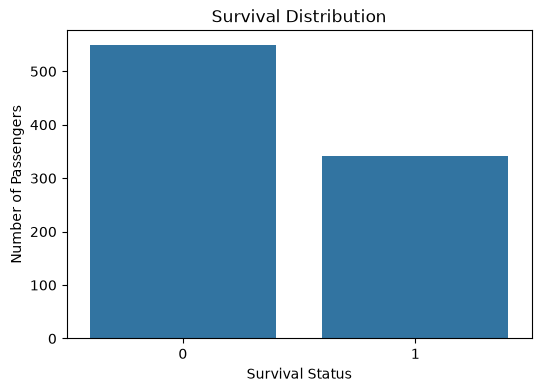

In [40]:
# Plot survival distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Survived"
)

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.savefig(
    "outputs/charts/survival_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The survival distribution shows that **more passengers did not survive than survived**. This indicates that the majority of passengers lost their lives in the disaster. The chart provides an initial understanding of the imbalance between survival outcomes before exploring the factors that may have influenced survival.

## 6.2 Survival by Gender

The **Sex** column represents the gender of each passenger.

- **male = Male Passenger**
- **female = Female Passenger**

Analyzing survival by gender helps determine whether gender influenced the likelihood of survival during the Titanic disaster.

In [41]:
# Display survival counts by gender
df_clean.groupby("Sex")["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

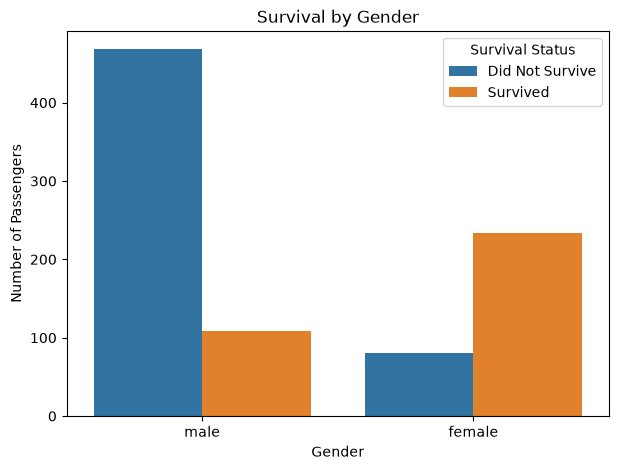

In [47]:
# Plot survival by gender

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

# Save chart
plt.savefig(
    "outputs/charts/survival_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization shows a clear difference in survival between male and female passengers. Most **female passengers survived** (233 survivors compared to 81 non-survivors), whereas the majority of **male passengers did not survive** (468 non-survivors compared to 109 survivors). This indicates that **gender played a significant role in passenger survival** during the Titanic disaster, with female passengers having a much higher likelihood of survival than male passengers.

## 6.3 Survival by Passenger Class

The **Pclass** column represents the passenger's ticket class.

- **1 = First Class**
- **2 = Second Class**
- **3 = Third Class**

Analyzing survival across passenger classes helps determine whether ticket class influenced the likelihood of survival.

In [43]:
# Display survival counts by passenger class
df_clean.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

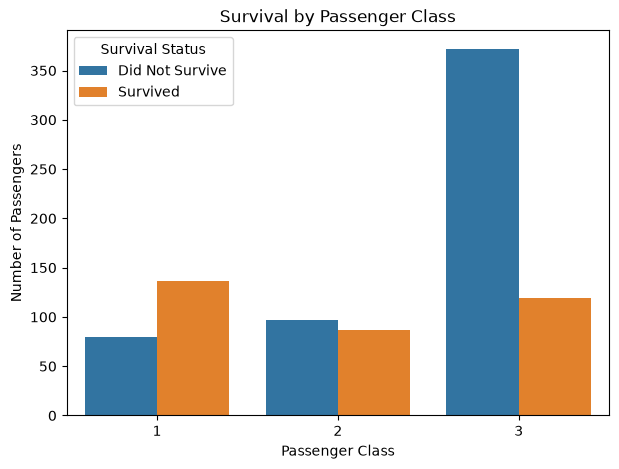

In [48]:
# Plot survival by passenger class

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

# Save chart
plt.savefig(
    "outputs/charts/survival_by_pclass.png",
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

In [45]:
import os

print(os.path.exists("outputs"))
print(os.path.exists("outputs/charts"))
print(os.path.isfile("outputs/charts"))
print(os.path.isdir("outputs/charts"))

True
True
False
True
